In [1]:
import matplotlib
import matplotlib.colors
import matplotlib.cm
import matplotlib.pyplot as plt
import matplotlib as mpl

#from typhon import plots
import numpy as np
import xarray as xr
import konrad
from cycler import cycler
from string import ascii_lowercase, ascii_uppercase
from pathlib import Path
import pandas as pd

xr.set_options(keep_attrs=True)

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


# Functions

In [2]:
def rad_cal(atmosphere, zenith_angle=85):
    plev = atmosphere.coords['plev']
    phlev = atmosphere.coords['phlev']
    #plev = pcap.plev.values
    #atmosphere = konrad.atmosphere.Atmosphere(plev)
    #print(pcap['O3_m'].squeeze().values[np.newaxis,:])
    #atmosphere['O3'][:] = pcap['O3_m'].squeeze().values[np.newaxis,1:]
    #atmosphere['H2O'][:] = pcap['H2O_m'].squeeze().values[np.newaxis,1:]#*10
    #atmosphere['T'][:] = pcap['te_m'].squeeze().values[np.newaxis,1:]

    surface = konrad.surface.SlabOcean.from_atmosphere(atmosphere)
    #surface['temperature'][:] = [300]
# Create cloud component (here clear-sky).
    cloud = konrad.cloud.ClearSky.from_atmosphere(atmosphere)
    
    # Create aerosol component (here clear-sky).
    #aerosol = konrad.aerosol.NoAerosol(atmosphere)
    
    # Setup the RRTMG radiation component (choose zenith angle and solar constant).
    rrtmg = konrad.radiation.RRTMG(zenith_angle=zenith_angle)#47.88)
    rrtmg.calc_radiation(atmosphere, surface, cloud)#, aerosol)  # Actual RT simulation
    #print(rrtmg['sw_flxu'].shape)
    ds_out_hr = xr.Dataset(
        data_vars=dict(
            lw_htngrt=(["plev"], rrtmg['lw_htngrt'].squeeze()),
            sw_htngrt=(["plev"], rrtmg['sw_htngrt'].squeeze()),
        ),
        coords=dict(plev = plev),
    )
    ds_out_fluxes = xr.Dataset(
        data_vars=dict(
            sw_flxu=(["phlev"], rrtmg['sw_flxu'].squeeze()),
            sw_flxd=(["phlev"], rrtmg['sw_flxd'].squeeze()),
            lw_flxu=(["phlev"], rrtmg['lw_flxu'].squeeze()),
            lw_flxd=(["phlev"], rrtmg['lw_flxd'].squeeze()),
        ),
        coords=dict(phlev = phlev),
    )
    return ds_out_hr, ds_out_fluxes#(rrtmg['lw_htngrt'].squeeze(), rrtmg['sw_htngrt'].squeeze)

def interpolate_mls(ds_mls, sel_time, atmosphere):
    ds_mls_interp = ds_mls.interp(pressure = atmosphere['plev'])
    temp = ds_mls_interp['O3'].sel(time = [sel_time.values]).fillna(0)/1e6
    diff_o3 = temp.values+atmosphere['O3']
    mask = diff_o3 < 0
    diff_o3[mask] = 0
    temp = ds_mls_interp['h2o'].sel(time = [sel_time.values]).fillna(0)/1e6
    diff_wv = temp.values+atmosphere['H2O']
    mask = diff_wv < 0
    diff_wv[mask] = 0
    return diff_o3, diff_wv

def perturb(ds_mls_sel, atmosphere, perturb_switch = 'both'):
    zenit_arr = np.arange(60,90,4)
    time_arr = ds_mls_sel.time[:]
    
    diff_time_ls = []
    for sel_time in time_arr:
        #print(sel_time)
        diff_o3, diff_wv = interpolate_mls(ds_mls_sel, sel_time, atmosphere)
        
        atmosphere2 = atmosphere.copy()
        if perturb_switch == 'both':
            atmosphere2['H2O'][0,:] = diff_wv
            atmosphere2['O3'][0,:] = diff_o3
        elif perturb_switch == 'H2O':
            atmosphere2['H2O'][0,:] = diff_wv
        elif perturb_switch == 'O3':
            atmosphere2['O3'][0,:] = diff_o3
    
        diff_ls = []
        for izenith in zenit_arr:
            ds_hr_wo, ds_fluxes_wo = rad_cal(atmosphere)
            ds_hr_w, ds_fluxes_w = rad_cal(atmosphere2)
            diff = ds_hr_w-ds_hr_wo
            diff.expand_dims('zenith')
            diff['zenith'] = [izenith]
            diff_ls.append(diff)
        
        diff_time_ls.append(xr.concat(diff_ls, dim = 'zenith'))

    return diff_time_ls

def process_diff(diff_time_ls,switch):
    diff_all = xr.concat(diff_time_ls, dim = 'time')
    #diff_all['time'] = time_arr
    diff_all['plev'] = diff_all.plev.values/100.
    diff_all['plev'].attrs['units'] = 'hPa'
    diff_all['plev'].attrs['long_name'] = 'pressure'
    diff_all = diff_all.expand_dims('perturb')
    diff_all['perturb'] = [switch]
    return diff_all

def process_chem(ds, deseasonalize=True, upper_limit=0.1, lower_limit=300):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))

def polar_sel(ds):
    ds_sel = ds[['O3_m','H2O_m']].sel(lat = slice(None,60)) # 'te_m',
    ds_sel = ds_sel.rename({'O3_m': 'O3', 'H2O_m': 'h2o', 'plev':'pressure'})
    weights = np.cos(np.deg2rad(ds_sel.lat))
    weights.name = "weights"
    #(ds_sel['H2O_m'].sel(plev = slice(100,None))*1e6).plot.hist()
    ds_sel_pcap = ds_sel.weighted(weights).mean(['lat','ens']).squeeze()
    ds_sel_pcap['pressure'] = ds_sel_pcap.pressure.values*100.
    return ds_sel_pcap

def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))


# Data loading

## atmosphere

In [3]:
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 128)
atmosphere = konrad.atmosphere.Atmosphere(plev)


In [13]:
plev

array([9.77592995e+04, 9.33945761e+04, 8.91620518e+04, 8.50615469e+04,
       8.10926183e+04, 7.72545726e+04, 7.35464796e+04, 6.99671863e+04,
       6.65153304e+04, 6.31893548e+04, 5.99875207e+04, 5.69079223e+04,
       5.39484995e+04, 5.11070525e+04, 4.83812544e+04, 4.57686642e+04,
       4.32667401e+04, 4.08728514e+04, 3.85842908e+04, 3.63982860e+04,
       3.43120106e+04, 3.23225954e+04, 3.04271383e+04, 2.86227143e+04,
       2.69063847e+04, 2.52752059e+04, 2.37262380e+04, 2.22565521e+04,
       2.08632381e+04, 1.95434110e+04, 1.82942177e+04, 1.71128421e+04,
       1.59965110e+04, 1.49424984e+04, 1.39481302e+04, 1.30107877e+04,
       1.21279113e+04, 1.12970033e+04, 1.05156307e+04, 9.78142708e+03,
       9.09209449e+03, 8.44540505e+03, 7.83920191e+03, 7.27140010e+03,
       6.73998698e+03, 6.24302246e+03, 5.77863896e+03, 5.34504111e+03,
       4.94050522e+03, 4.56337857e+03, 4.21207853e+03, 3.88509144e+03,
       3.58097142e+03, 3.29833899e+03, 3.03587961e+03, 2.79234212e+03,
      

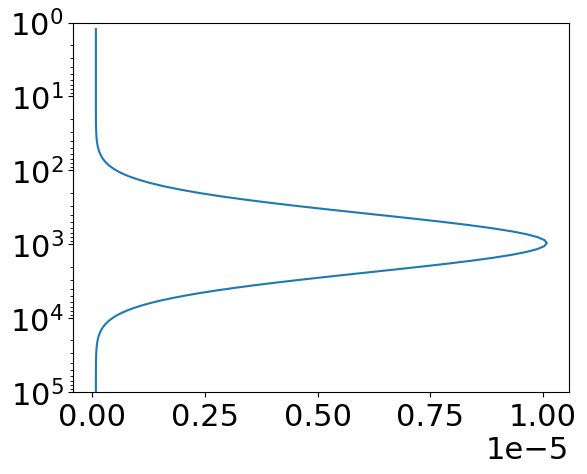

In [49]:
z_km = -7.0 * np.log(plev[:-1]/100. / 1000.0)
ozone = 0.08e-6 + 10.0e-6 * np.exp(-1 * ((z_km - 32.5) / 9.0) ** 2)
plt.plot(ozone, plev[:-1])
plt.ylim(bottom=100000, top = 1)
plt.yscale('log')

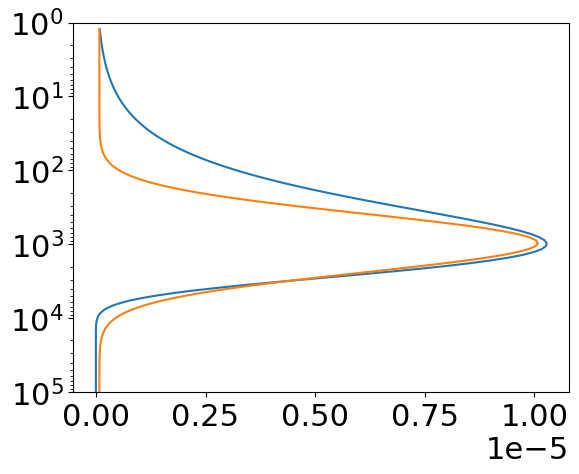

In [50]:
plt.plot(atmosphere['O3'].squeeze(), plev[:-1])
plt.plot(ozone, plev[:-1])

plt.ylim(bottom=100000, top = 1)
plt.yscale('log')

(100000.0, 0.0)

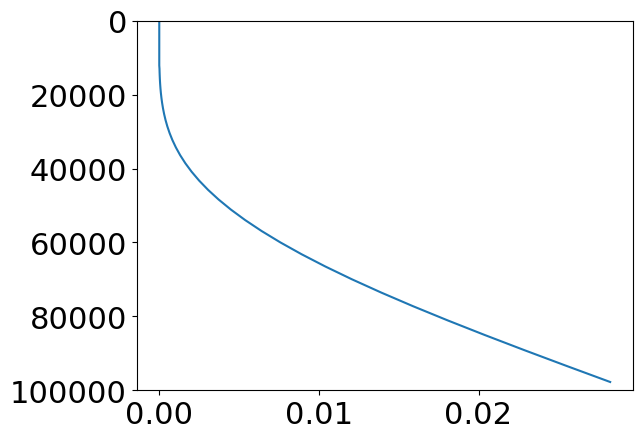

In [22]:
plt.plot(atmosphere['H2O'].squeeze(), plev[:-1])
plt.ylim(bottom=100000, top = 0)

In [4]:
s_year = 2024
e_year = 2025
s_month = 9
e_month = 3
time_start = f"{s_year}-{s_month:02d}"
time_end = f"{e_year}-{e_month:02d}"
ds_mls_sel =xr.open_dataset(f'O3+WV_{s_year}{s_month:02d}-{e_year}{e_month:02d}.nc')
ds_mls_sel

<xarray.Dataset> Size: 4kB
Dimensions:   (time: 7, pressure: 37)
Coordinates:
  * time      (time) datetime64[ns] 56B 2024-09-30 2024-10-31 ... 2025-03-31
  * pressure  (pressure) float32 148B 1.778e+04 1.468e+04 ... 2.154 1.0
Data variables:
    O3        (time, pressure) float64 2kB ...
    h2o       (time, pressure) float64 2kB ...
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [23]:
diff_time_ls

[<xarray.Dataset> Size: 17kB
 Dimensions:    (zenith: 8, plev: 127)
 Coordinates:
   * zenith     (zenith) int64 64B 60 64 68 72 76 80 84 88
   * plev       (plev) float64 1kB 9.555e+04 9.125e+04 8.709e+04 ... 1.308 1.144
 Data variables:
     lw_htngrt  (zenith, plev) float64 8kB 0.0005208 0.0005314 ... 0.0002152
     sw_htngrt  (zenith, plev) float64 8kB -0.0001395 -0.0001437 ... 2.298e-06,
 <xarray.Dataset> Size: 17kB
 Dimensions:    (zenith: 8, plev: 127)
 Coordinates:
   * zenith     (zenith) int64 64B 60 64 68 72 76 80 84 88
   * plev       (plev) float64 1kB 9.555e+04 9.125e+04 8.709e+04 ... 1.308 1.144
 Data variables:
     lw_htngrt  (zenith, plev) float64 8kB 0.0008017 0.000816 ... 0.0001875
     sw_htngrt  (zenith, plev) float64 8kB -0.0001869 -0.0001919 ... 2.733e-06,
 <xarray.Dataset> Size: 17kB
 Dimensions:    (zenith: 8, plev: 127)
 Coordinates:
   * zenith     (zenith) int64 64B 60 64 68 72 76 80 84 88
   * plev       (plev) float64 1kB 9.555e+04 9.125e+04 8.709e+04 ...

In [5]:
switch_ls = ['both','H2O','O3']
temp_ls = []
for switch in switch_ls:
    diff_time_ls = perturb(ds_mls_sel, atmosphere, perturb_switch=switch)    
    temp = process_diff(diff_time_ls, switch)
    temp_ls.append(temp)

In [6]:
diff_all_all = xr.concat(temp_ls, dim = 'perturb')
diff_all_all['SUM'] = diff_all_all['lw_htngrt']+diff_all_all['sw_htngrt']
diff_all_all = diff_all_all.rename({'lw_htngrt': 'LW', 'sw_htngrt': 'SW'})
#diff_all_all.to_netcdf(f'MLS_RRTMG_{time_start}-{time_end}.nc')

MLS_RRTMG_2024-09--2025-03.pdf


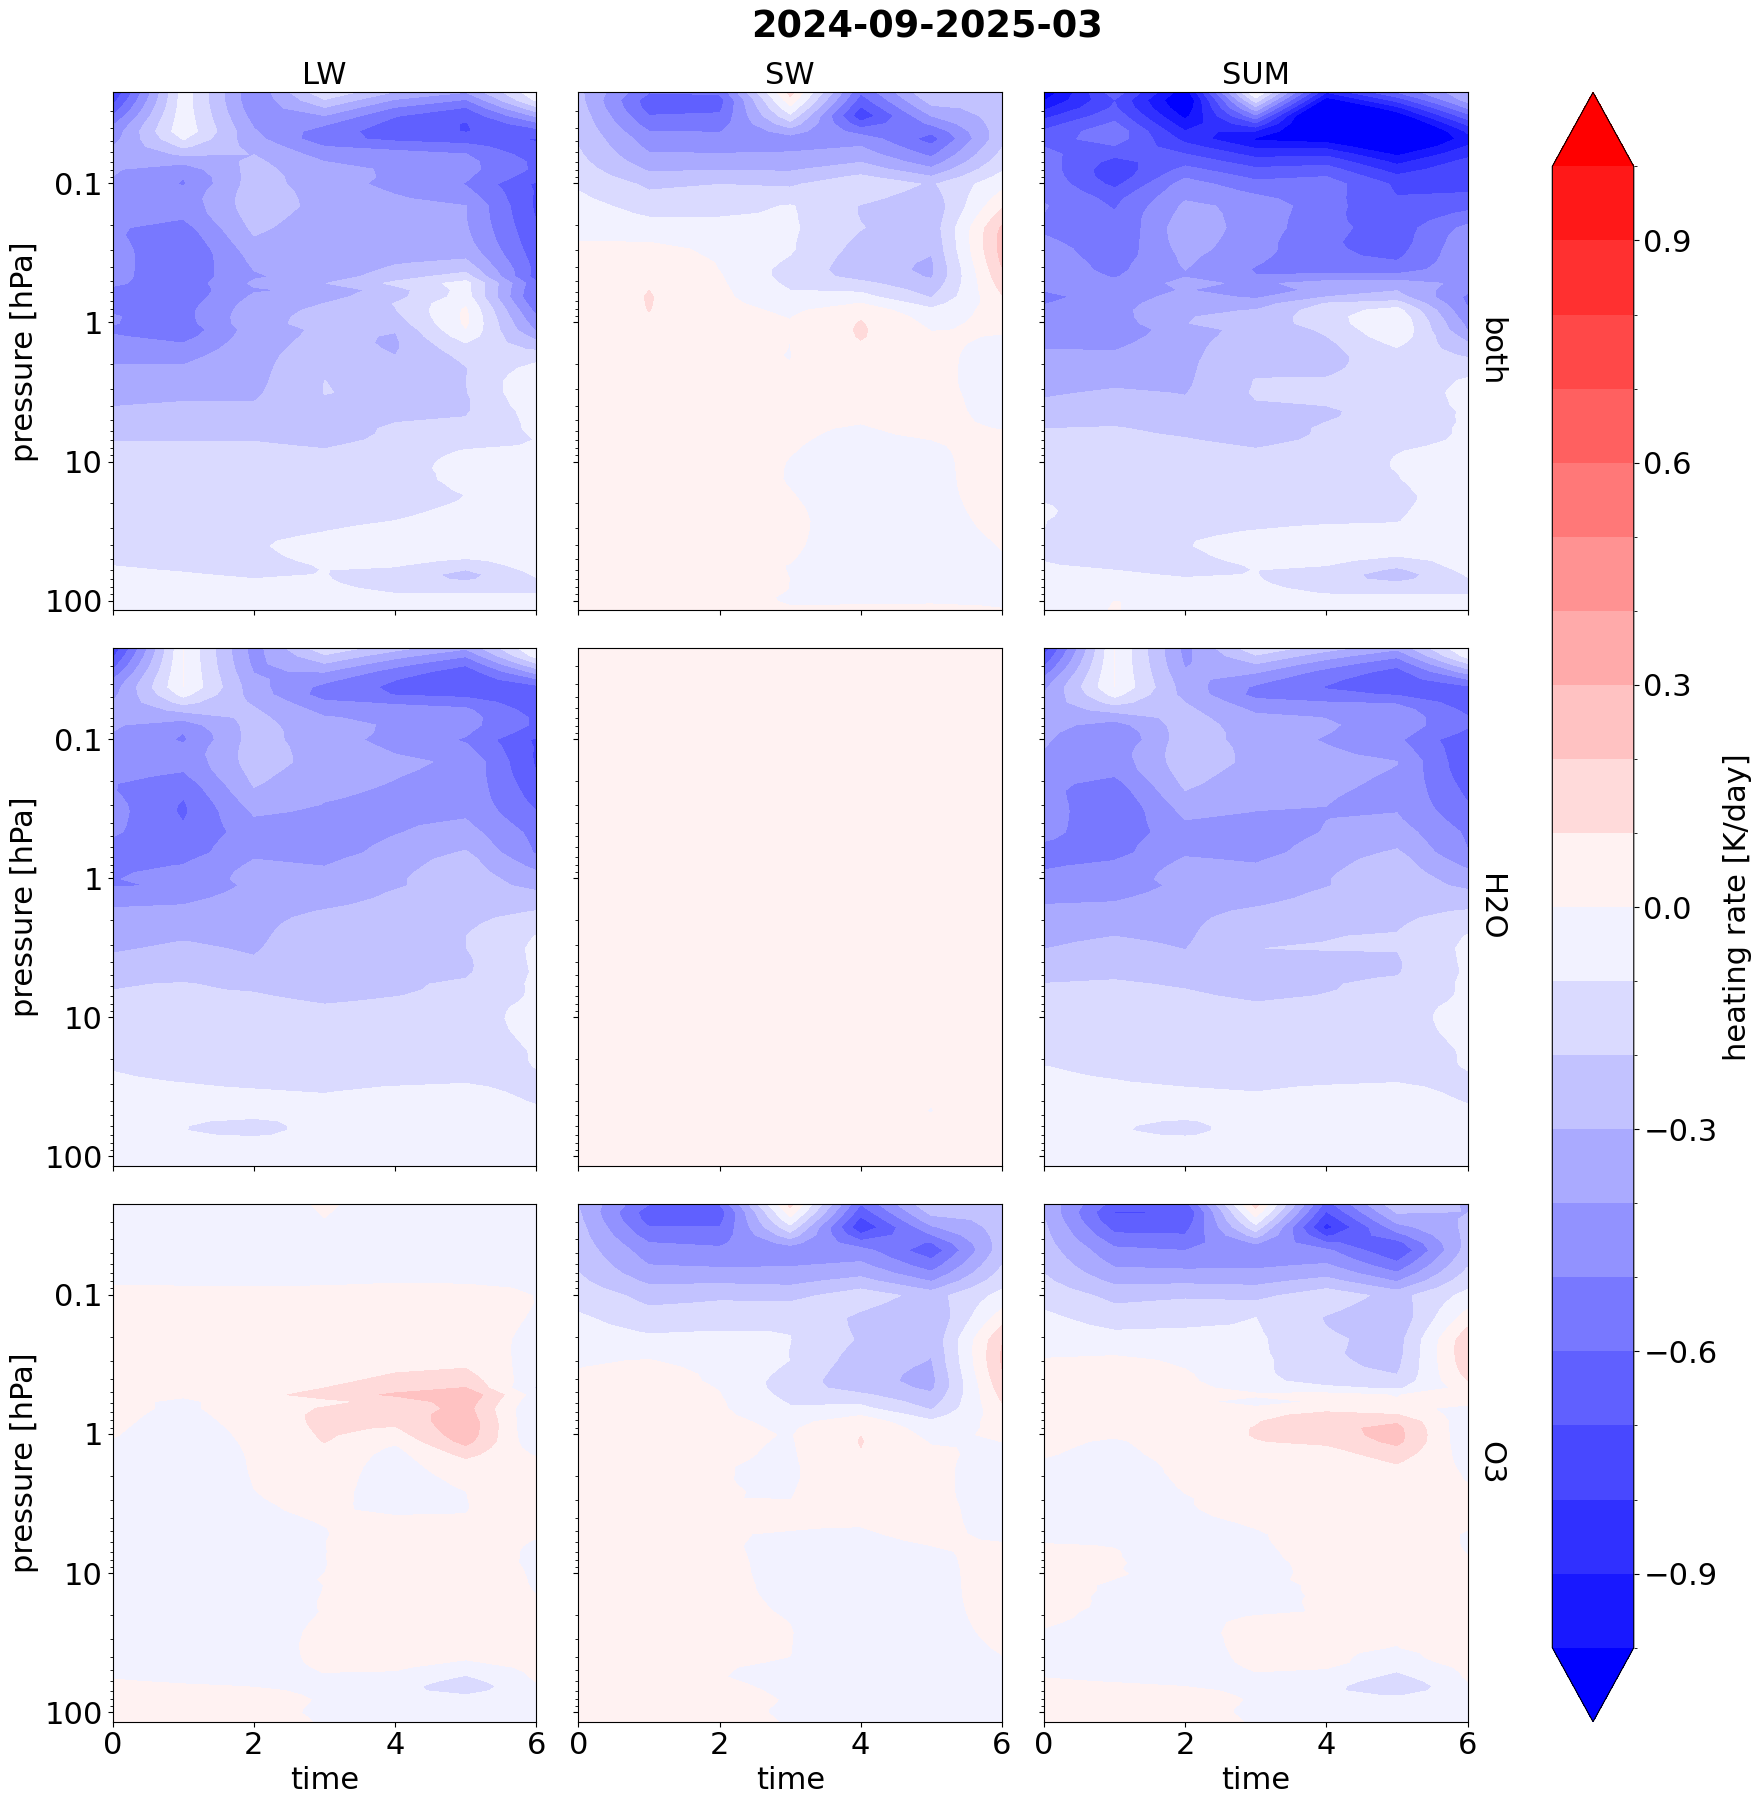

In [7]:
plt.rcParams.update({"font.size": 22})
temp_plot = diff_all_all.sel(
    plev = slice(120,0.02)
).to_array().mean('zenith')
temp_plot.name = 'hr'
temp_plot.attrs['units'] = 'K/day'
temp_plot.attrs['long_name'] = 'heating rate'

p = temp_plot.plot.contourf(
    x = 'time', y = 'plev', yincrease = False, 
    robust = True, levels = np.linspace(-1,1,21), 
    col = 'variable', row = 'perturb',
    extend = 'both', cmap = 'bwr',
    size = 6
)
p.set_titles(template = '{value}')
p.fig.suptitle(f'{time_start}-{time_end}', y = 1.01, fontweight = 'bold')

for ax in p.axes.flat:
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)


outfile = f'MLS_RRTMG_{time_start}--{time_end}.pdf'
print(outfile)
plt.savefig(outfile, bbox_inches="tight")